# Rare-Disease Synthetic Data Augmentation — Day 2: Simple Augmentation Baselines

Day 1 gave the control: ResNet-18 on real data only → **DF F1 = 0.50** (recall 0.45).
Today adds the reference points the GAN must beat later, using the **same split, test set, model and training recipe**.

**Design — equal extra budget.** Every method keeps all real training images and adds the **same number (`N_EXTRA = 500`)
of extra rare-class (DF) samples**. Only *how* those extras are made changes:

| Configuration | The 500 extra DF samples are… |
|---|---|
| `classic_aug` | real DF images, randomly rotated / flipped / cropped / brightness-jittered (new random version every epoch) |
| `smote_interp` | new images blended from two real DF images of *different* lesions that look alike (SMOTE-style) |
| `oversample_only` | plain copies of real DF images — **extra control**: shows how much of any gain is just "seeing DF more often" |

The GAN on Day 4 will add its 500 synthetic images in exactly the same way.

**Before running:** upload `rare-disease-aug-day2.zip` to the top level of *My Drive* (it only adds/updates code — your Day 1 data and results are untouched).
Then `Runtime → Change runtime type → T4 GPU` and `Runtime → Run all`. Time ≈ 15–20 min (three training runs).

## 0 · Setup

In [5]:
!nvidia-smi --query-gpu=name,memory.total --format=csv || echo "⚠️ No GPU — Runtime > Change runtime type > T4 GPU"

name, memory.total [MiB]
Tesla T4, 15360 MiB


In [6]:
import os, sys, zipfile
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

PROJECT_DIR = Path(os.environ.get('RDA_PROJECT_DIR', '/content/drive/MyDrive/rare-disease-aug'))
RAW_DIR     = Path(os.environ.get('RDA_RAW_DIR', '/content/ham10000_raw'))   # not needed today

# Apply the Day 2 code update (adds src/augment.py, src/compare.py and this notebook; data/results untouched)
UPDATE_ZIP = PROJECT_DIR.parent / 'rare-disease-aug-day2.zip'
if UPDATE_ZIP.exists():
    zipfile.ZipFile(UPDATE_ZIP).extractall(PROJECT_DIR.parent)
    print('Code updated from', UPDATE_ZIP.name)
assert (PROJECT_DIR / 'src' / 'augment.py').exists(), f'Upload rare-disease-aug-day2.zip to {PROJECT_DIR.parent} first'

os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR))
print('Project dir:', PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Code updated from rare-disease-aug-day2.zip
Project dir: /content/drive/MyDrive/rare-disease-aug


In [7]:
import json
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from IPython.display import display

from src.config import Paths, TrainConfig, CLASS_CODES, CLASS_NAMES
from src.data.explore import build_metadata
from src.data.split import make_split, split_summary
from src.data.preprocess import build_image_cache
from src.data.dataset import attach_cache_index
from src.augment import RealPlusExtra, classic_rare_transform, sample_rare_indices, smote_rare_images
from src.compare import comparison_table, plot_rare_metrics, show_augmented_examples, show_smote_examples
from src.train import run_experiment

pd.set_option('display.width', 160)
paths = Paths(PROJECT_DIR, RAW_DIR)
print(f'torch {torch.__version__} | CUDA: {torch.cuda.is_available()}')

torch 2.11.0+cu128 | CUDA: True


## 1 · Reload the Day 1 state (no re-download)

Rare class, the fixed split and the resized image cache all come from Drive.

In [8]:
info = json.loads(paths.dataset_info_json.read_text())
RARE = info['rare_class']
RARE_IDX = CLASS_CODES.index(RARE)

meta = build_metadata(paths)                       # loads the saved metadata.csv
split = make_split(meta, paths, seed=42)           # reuses data/splits/split_seed42.csv — same test set as Day 1
images = build_image_cache(meta, paths, size=224)  # reuses the 224 px cache, loads it into RAM
split = attach_cache_index(split, meta)
train_df = split[split.split == 'train'].reset_index(drop=True)

n_rare_train = int((train_df.label_idx == RARE_IDX).sum())
print(f'Rare class: {RARE} ({CLASS_NAMES[RARE]}) | real {RARE} training images: {n_rare_train} of {len(train_df)}')

log = pd.read_csv(paths.results_log)
assert (log.config == 'baseline_no_aug').any(), 'Day 1 baseline row not found in results_log.csv'
display(log[log.config == 'baseline_no_aug'][['config', 'seed', 'rare_precision', 'rare_recall', 'rare_f1', 'rare_auroc']])

[reuse] raw data not on disk; loading saved /content/drive/MyDrive/rare-disease-aug/data/processed/metadata.csv
[reuse] existing split /content/drive/MyDrive/rare-disease-aug/data/splits/split_seed42.csv
[reuse] image cache /content/drive/MyDrive/rare-disease-aug/data/processed/images_224px_uint8.npy  shape=(10015, 224, 224, 3)
Loading images_224px_uint8.npy into RAM ...
Rare class: DF (Dermatofibroma) | real DF training images: 71 of 6981


,config,seed,rare_precision,rare_recall,rare_f1,rare_auroc
0,baseline_no_aug,42,0.5625,0.45,0.5,0.9507


### Shared settings

Identical to Day 1 for every run. `N_EXTRA` will be reused unchanged for the GAN on Day 4.

In [9]:
N_EXTRA = 500    # extra rare-class samples added by every method
SEED = 42

def make_cfg(run_name, config_name, notes):
    return TrainConfig(run_name=run_name, config_name=config_name, arch='resnet18', pretrained=True,
                       epochs=15, batch_size=64, lr=1e-4, weight_decay=1e-4,
                       seed=SEED, split_seed=42, rare_class=RARE, notes=notes)

extra_idx = sample_rare_indices(train_df, RARE_IDX, N_EXTRA, seed=SEED)   # which real DF images get re-used
print(f'{RARE} share of training data: {n_rare_train / len(train_df):.1%} → '
      f'{(n_rare_train + N_EXTRA) / (len(train_df) + N_EXTRA):.1%} after adding {N_EXTRA} extras')

DF share of training data: 1.0% → 7.6% after adding 500 extras


## 2 · Classic augmentation (rare class only)

Random flips and 90° turns (dermoscopy has no 'up'), a further rotation up to ±20° with **mirror padding**, random crop (75–100 % of the area) and brightness/contrast jitter.

Why mirror padding: a normal rotation leaves black corners. Only DF images are augmented, so black corners would appear on DF images only and the model could learn "black corners = DF" — a shortcut that isn't in the test images.
Applied **only** to the 500 extra DF samples; every other image is used exactly as on Day 1.

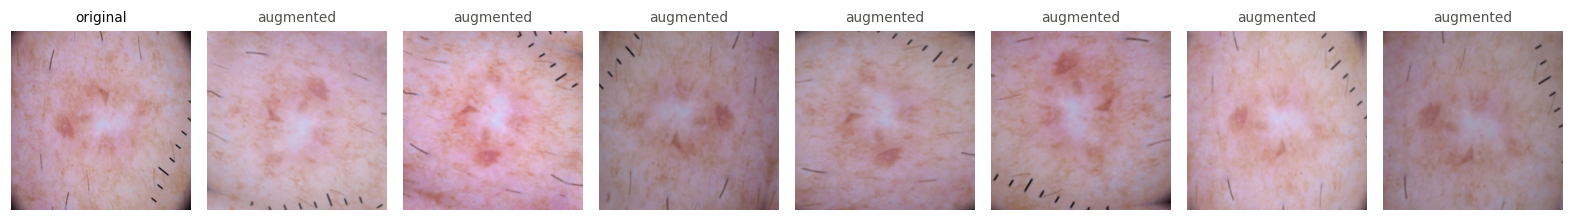

In [10]:
classic_tf = classic_rare_transform(224)
show_augmented_examples(images, int(extra_idx[0]), classic_tf, paths.figures_dir / 'day2_classic_aug_examples.png')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


Device: cuda | AMP: True | train=7481 (rare DF: 571) | val=1532 | test=1502
ep 01/15 | loss 0.6687 / val 0.5612 | val acc 0.808 macroF1 0.607 | DF P 0.50 R 0.33 F1 0.40 (pred 16) | 43s  *best*
ep 02/15 | loss 0.2412 / val 0.5902 | val acc 0.808 macroF1 0.598 | DF P 0.33 R 0.29 F1 0.31 (pred 21) | 20s
ep 03/15 | loss 0.0716 / val 0.6021 | val acc 0.810 macroF1 0.620 | DF P 0.50 R 0.25 F1 0.33 (pred 12) | 19s  *best*
ep 04/15 | loss 0.0235 / val 0.6730 | val acc 0.804 macroF1 0.592 | DF P 0.23 R 0.42 F1 0.29 (pred 44) | 18s
ep 05/15 | loss 0.0098 / val 0.6724 | val acc 0.809 macroF1 0.608 | DF P 0.24 R 0.38 F1 0.30 (pred 37) | 18s
ep 06/15 | loss 0.0050 / val 0.6402 | val acc 0.822 macroF1 0.619 | DF P 0.33 R 0.29 F1 0.31 (pred 21) | 20s
ep 07/15 | loss 0.0043 / val 0.6980 | val acc 0.819 macroF1 0.626 | DF P 0.42 R 0.33 F1 0.37 (pred 19) | 19s  *best*
ep 08/15 | loss 0.0048 / val 0.6720 | val acc 0.816 macroF1 0.624 | DF P 0.21 R 0.33 F1 0.26 (pred 38) | 19s
ep 09/15 | loss 0.0029 / val

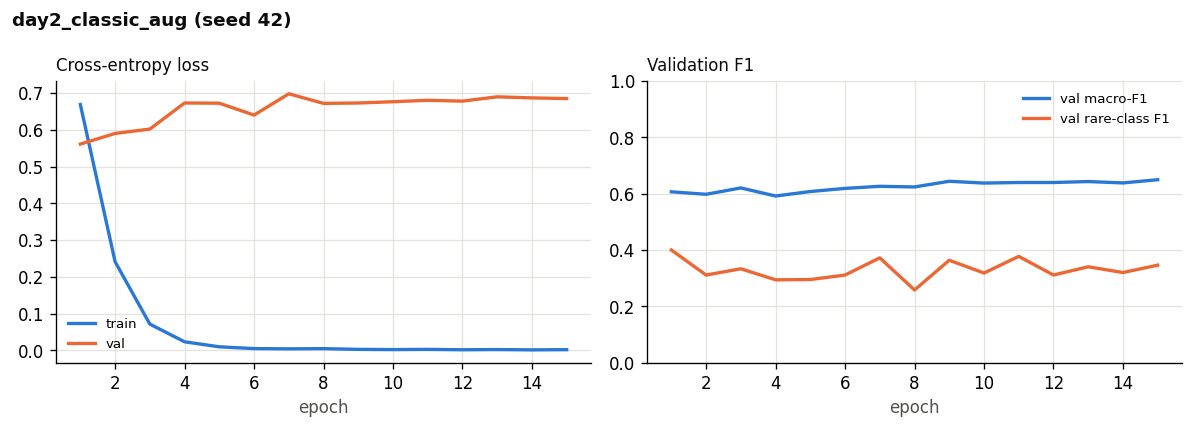

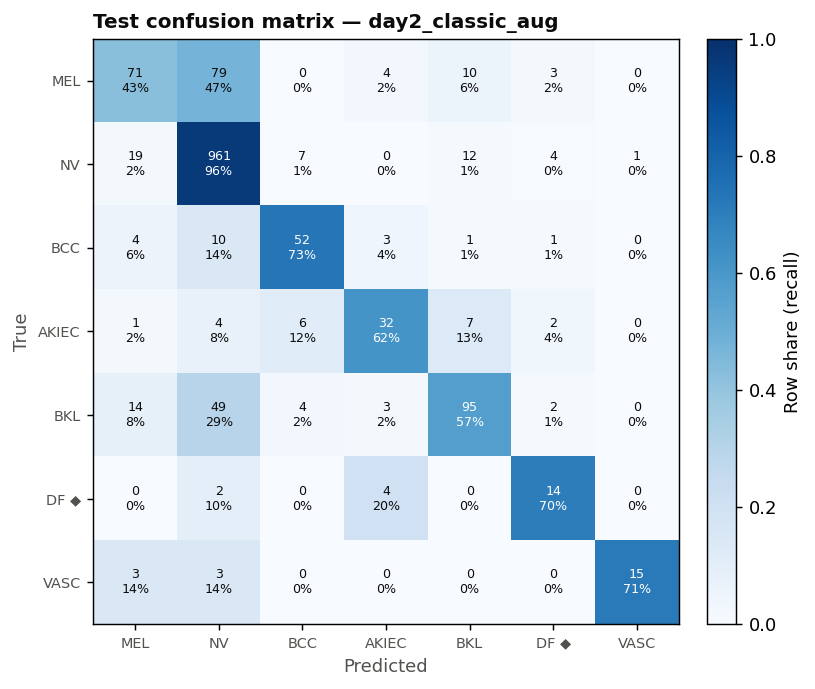


Saved run artefacts to /content/drive/MyDrive/rare-disease-aug/results/runs/day2_classic_aug_seed42
Appended results row to /content/drive/MyDrive/rare-disease-aug/results/results_log.csv


In [11]:
ds_classic = RealPlusExtra(images, train_df, RARE_IDX, extra_cache_idx=extra_idx, extra_transform=classic_tf)
out_classic = run_experiment(
    make_cfg('day2_classic_aug', 'classic_aug',
             f'Day 2: real data + {N_EXTRA} classic-augmented {RARE} copies (flip/rot/crop/jitter)'),
    paths, images, split, train_dataset=ds_classic, n_synthetic=N_EXTRA)

## 3 · SMOTE-style interpolation

SMOTE creates new minority samples *between* existing ones. For images:

1. Embed each real DF training image with an ImageNet ResNet-18 (only to find look-alikes).
2. For a random DF image **A**, pick **B** among its 5 most similar DF images from a **different lesion**.
3. New image = A + λ·(B − A), with λ random in [0, 1].

The 500 blended images are generated once and saved to Drive. Expect some "double exposure" ghosting —
a known weakness of pixel-space blending, and a useful contrast with the GAN later.

500 SMOTE images | built from 71 of 71 real DF images | mean λ = 0.51


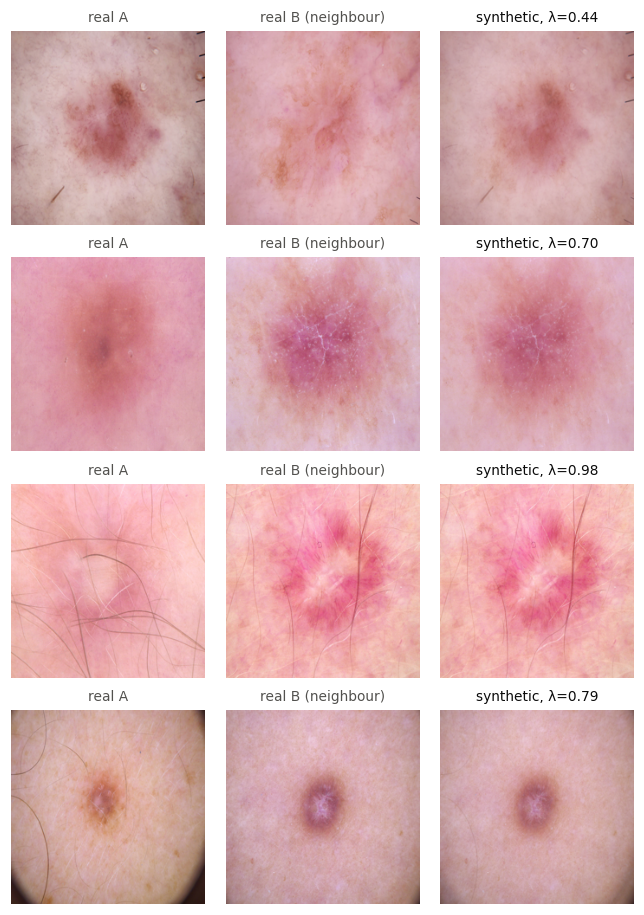

In [12]:
smote_imgs, smote_prov = smote_rare_images(images, train_df, RARE_IDX, N_EXTRA, k=5, seed=SEED, feature_space='resnet')

syn_dir = paths.project_dir / 'data' / 'synthetic'
syn_dir.mkdir(parents=True, exist_ok=True)
np.save(syn_dir / f'smote_{RARE}_{N_EXTRA}.npy', smote_imgs)
smote_prov.to_csv(syn_dir / f'smote_{RARE}_{N_EXTRA}_provenance.csv', index=False)

used = pd.unique(pd.concat([smote_prov.a_image_id, smote_prov.b_image_id]))
print(f'{len(smote_imgs)} SMOTE images | built from {len(used)} of {n_rare_train} real {RARE} images | '
      f'mean λ = {smote_prov.lam.mean():.2f}')

id_to_cache = dict(zip(split.image_id, split.cache_idx))
show_smote_examples(images, id_to_cache, smote_imgs, smote_prov, paths.figures_dir / 'day2_smote_examples.png')

Device: cuda | AMP: True | train=7481 (rare DF: 571) | val=1532 | test=1502
ep 01/15 | loss 0.6586 / val 0.5296 | val acc 0.808 macroF1 0.612 | DF P 0.53 R 0.38 F1 0.44 (pred 17) | 15s  *best*
ep 02/15 | loss 0.2273 / val 0.5740 | val acc 0.806 macroF1 0.606 | DF P 0.58 R 0.29 F1 0.39 (pred 12) | 14s
ep 03/15 | loss 0.0643 / val 0.6061 | val acc 0.811 macroF1 0.606 | DF P 0.45 R 0.21 F1 0.29 (pred 11) | 14s
ep 04/15 | loss 0.0185 / val 0.6159 | val acc 0.820 macroF1 0.625 | DF P 0.55 R 0.25 F1 0.34 (pred 11) | 14s  *best*
ep 05/15 | loss 0.0079 / val 0.6315 | val acc 0.821 macroF1 0.631 | DF P 0.50 R 0.25 F1 0.33 (pred 12) | 14s  *best*
ep 06/15 | loss 0.0050 / val 0.6574 | val acc 0.822 macroF1 0.628 | DF P 0.50 R 0.21 F1 0.29 (pred 10) | 14s
ep 07/15 | loss 0.0041 / val 0.6676 | val acc 0.826 macroF1 0.641 | DF P 0.58 R 0.29 F1 0.39 (pred 12) | 14s  *best*
ep 08/15 | loss 0.0025 / val 0.6679 | val acc 0.828 macroF1 0.627 | DF P 0.56 R 0.21 F1 0.30 (pred 9) | 14s
ep 09/15 | loss 0.002

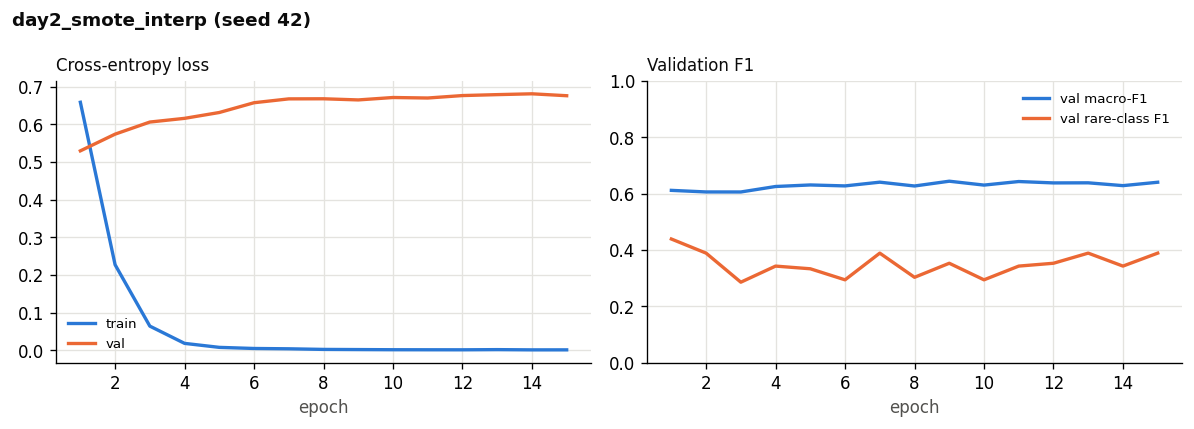

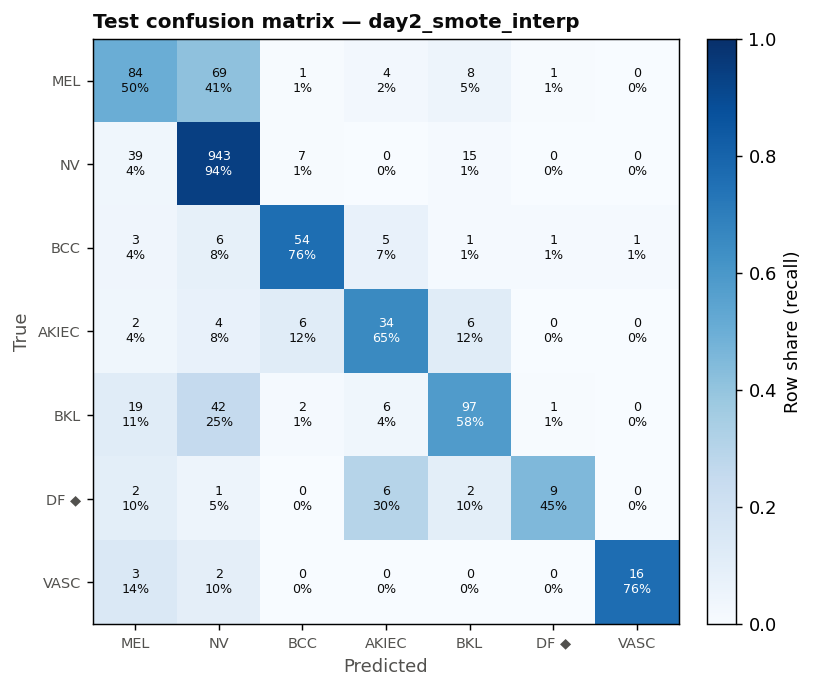


Saved run artefacts to /content/drive/MyDrive/rare-disease-aug/results/runs/day2_smote_interp_seed42
Appended results row to /content/drive/MyDrive/rare-disease-aug/results/results_log.csv


In [13]:
ds_smote = RealPlusExtra(images, train_df, RARE_IDX, extra_array=smote_imgs)
out_smote = run_experiment(
    make_cfg('day2_smote_interp', 'smote_interp',
             f'Day 2: real data + {N_EXTRA} SMOTE-style {RARE} blends (k=5, different lesions, ResNet features)'),
    paths, images, split, train_dataset=ds_smote, n_synthetic=N_EXTRA)

## 4 · Extra control: oversampling only

The same 500 DF copies as in section 2, but **unchanged**. If this scores about as well as classic augmentation,
the gain comes from rebalancing, not from new visual variation — important for judging the GAN honestly on Day 4.
Set `RUN_OVERSAMPLE_CONTROL = False` to skip (saves ~5 min).

Device: cuda | AMP: True | train=7481 (rare DF: 571) | val=1532 | test=1502
ep 01/15 | loss 0.6587 / val 0.5179 | val acc 0.819 macroF1 0.619 | DF P 0.59 R 0.42 F1 0.49 (pred 17) | 14s  *best*
ep 02/15 | loss 0.2198 / val 0.5877 | val acc 0.811 macroF1 0.616 | DF P 0.50 R 0.29 F1 0.37 (pred 14) | 14s
ep 03/15 | loss 0.0637 / val 0.5985 | val acc 0.811 macroF1 0.628 | DF P 0.55 R 0.25 F1 0.34 (pred 11) | 14s  *best*
ep 04/15 | loss 0.0180 / val 0.6097 | val acc 0.823 macroF1 0.655 | DF P 0.70 R 0.29 F1 0.41 (pred 10) | 14s  *best*
ep 05/15 | loss 0.0081 / val 0.6190 | val acc 0.821 macroF1 0.637 | DF P 0.67 R 0.25 F1 0.36 (pred 9) | 14s
ep 06/15 | loss 0.0042 / val 0.6347 | val acc 0.828 macroF1 0.644 | DF P 0.67 R 0.25 F1 0.36 (pred 9) | 14s
ep 07/15 | loss 0.0034 / val 0.6519 | val acc 0.824 macroF1 0.634 | DF P 0.75 R 0.25 F1 0.38 (pred 8) | 14s
ep 08/15 | loss 0.0028 / val 0.6818 | val acc 0.825 macroF1 0.639 | DF P 0.75 R 0.25 F1 0.38 (pred 8) | 14s
ep 09/15 | loss 0.0022 / val 0.6

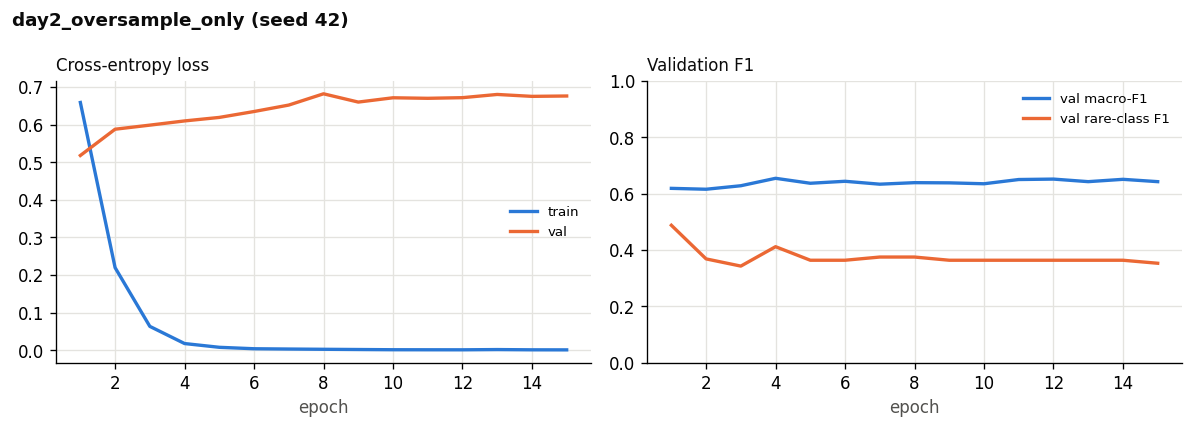

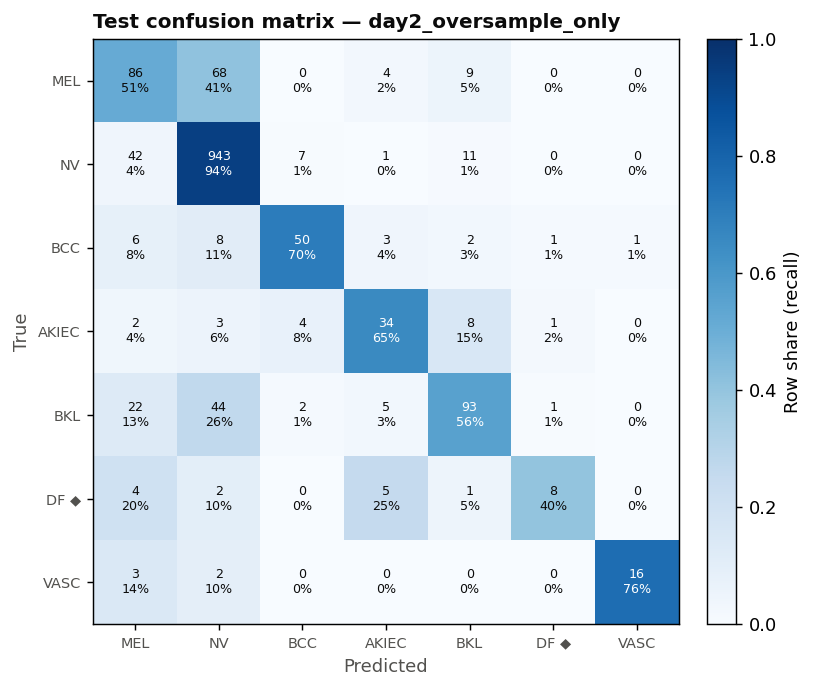


Saved run artefacts to /content/drive/MyDrive/rare-disease-aug/results/runs/day2_oversample_only_seed42
Appended results row to /content/drive/MyDrive/rare-disease-aug/results/results_log.csv


In [14]:
RUN_OVERSAMPLE_CONTROL = True

if RUN_OVERSAMPLE_CONTROL:
    ds_over = RealPlusExtra(images, train_df, RARE_IDX, extra_cache_idx=extra_idx)
    out_over = run_experiment(
        make_cfg('day2_oversample_only', 'oversample_only',
                 f'Day 2 control: real data + {N_EXTRA} un-augmented {RARE} copies'),
        paths, images, split, train_dataset=ds_over, n_synthetic=N_EXTRA)

## 5 · Comparison with the Day 1 baseline

Same test images for every row. `Δ` columns are the change versus the baseline.

,n_extra,n_train_rare,test_accuracy,test_macro_f1,rare_precision,rare_recall,recall_95ci,rare_f1,rare_auroc,best_epoch,Δrare_recall,Δrare_f1
Baseline (no aug),0,71,0.820,0.684,0.562,0.45,0.26–0.66,0.500,0.951,14,0.00,0.000
Oversample only,500,571,0.819,0.689,0.727,0.40,0.22–0.61,0.516,0.972,4,-0.05,0.016
Classic aug,500,571,0.826,0.698,0.538,0.70,0.48–0.85,0.609,0.960,15,0.25,0.109
SMOTE interp.,500,571,0.824,0.700,0.750,0.45,0.26–0.66,0.562,0.968,9,0.00,0.062


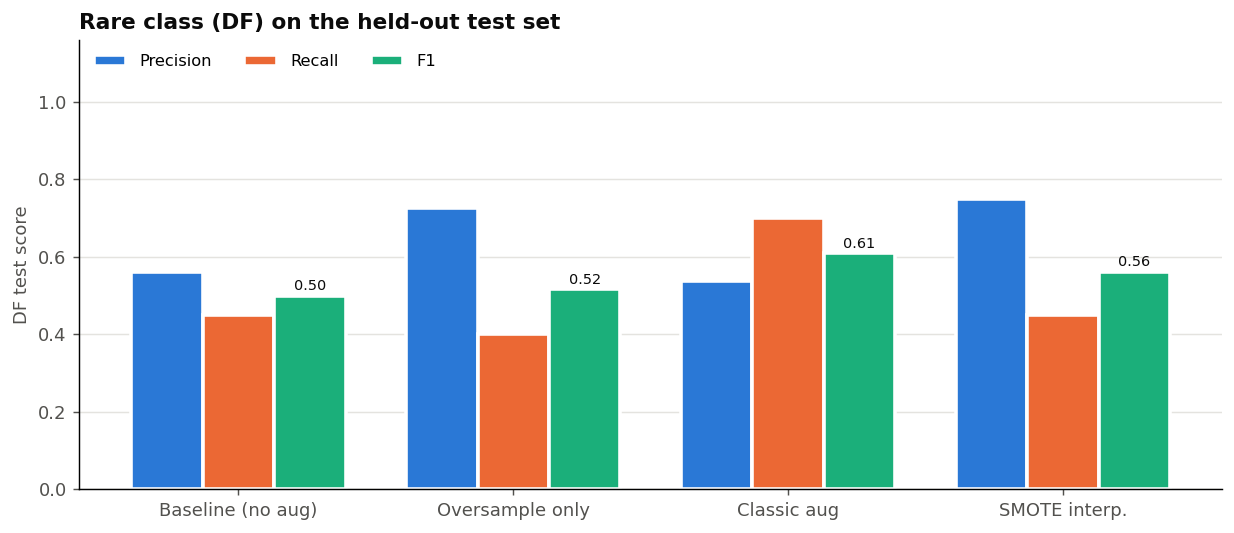

Reminder: only 20 DF test images → one image = 5 points of recall.
Compare the recall_95ci ranges: where they overlap a lot, one run cannot tell the methods apart. Days 6–7 repeat every configuration over several seeds to settle it.


In [15]:
table = comparison_table(paths.results_log, seed=SEED)
display(table)
plot_rare_metrics(table, RARE, paths.figures_dir / 'day2_rare_class_comparison.png')

n_test_rare = int(((split.split == 'test') & (split.label_idx == RARE_IDX)).sum())
print(f'Reminder: only {n_test_rare} {RARE} test images → one image = {100 / n_test_rare:.0f} points of recall.')
print('Compare the recall_95ci ranges: where they overlap a lot, one run cannot tell the methods apart. '
      'Days 6–7 repeat every configuration over several seeds to settle it.')

## ✅ Day 2 checklist

`File → Download → Download .ipynb` and send the file back. I'll check:

* the example grids (classic augmentation and SMOTE blends) look sensible
* all three runs finished and appended rows to `results_log.csv`
* the comparison table: how classic augmentation and SMOTE compare with the baseline **and** with plain oversampling

Day 3 (the GAN) starts only after that check.